In [31]:
!pip install langchain_google_genai

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [ ]:
# Set your Google API key here
api_key = ""  # Replace with your actual key

if not api_key or api_key == "YOUR_API_KEY_HERE":
    raise ValueError("Please set api_key to your actual GOOGLE_API_KEY")

In [6]:
class State(TypedDict):
    question : str
    answer_eng : str
    answer_hin : str 

In [16]:
translate_text_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    api_key=api_key,
    streaming=True
)
generate_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    api_key=api_key,
    streaming=True
)

In [8]:
def translate_node(state : State) :
    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()

    translated_text = translate_text_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

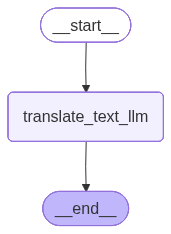

In [9]:
subgraph_builder = StateGraph(State)

subgraph_builder.add_node('translate_text_llm', translate_node)

subgraph_builder.add_edge(START, 'translate_text_llm')
subgraph_builder.add_edge('translate_text_llm', END)

subgraph = subgraph_builder.compile()
subgraph

In [10]:
def generate_answer(state: State):

    answer = generate_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
parent_builder = StateGraph(State)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

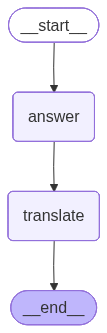

In [12]:
graph = parent_builder.compile()

graph

In [ ]:

graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the **atomic and subatomic levels**.\n\nIt\'s essentially the physics of the *very, very small*.\n\nHere\'s a breakdown of what that means:\n\n1.  **The World of the Small:**\n    *   While classical physics (like Newton\'s laws) works perfectly for understanding objects we can see and touch (planets, cars, apples), it completely breaks down when you go down to the scale of atoms, electrons, photons, and other elementary particles.\n    *   Quantum physics provides the rules for how these tiny particles behave, interact, and form the building blocks of everything around us.\n\n2.  **"Quantum" Means Discrete Packets:**\n    *   The word "quantum" comes from the Latin word for "how much" and refers to the idea that certain physical properties, like energy, come in discrete, indivisible packets or "